In [2]:
from dGbyG.api import Compound
import os
import base64
import io
from tqdm import tqdm
import pandas as pd

In [3]:
base_dir = '/zhongj/dGbyG/dGbyG/data/bigg/'
output_path = '/mnt/418data2/zhongjie/website/BIGG/image_bigg_id/'
metabolites_name = 'bigg_models_metabolites_with_mol.txt'
df = pd.read_csv(os.path.join(base_dir,metabolites_name),sep='\t')

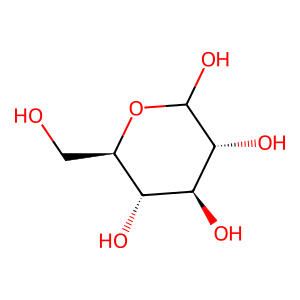

In [4]:
comp= Compound(mol ='C00031' ,mol_type = 'kegg')
comp.image

12dgr140


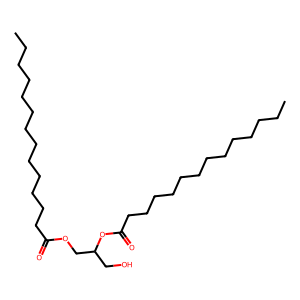

In [5]:
id1 = df['universal_bigg_id'][1]
print(id1)
comp=Compound(mol=id1,mol_type = 'bigg')
display(comp.image)

In [6]:
all_ids = df['universal_bigg_id']
for item_id in tqdm(all_ids, desc=('progress')):
    try:
        comp =Compound(mol = item_id,mol_type='bigg')
        img = comp.image
        if img:
            img_io = io.BytesIO()
            img.save(img_io,format = 'PNG')
            img_base64 = base64.b64encode(img_io.getvalue()).decode('utf-8')
    
            with open(os.path.join(output_path,f'{item_id}.txt'),'w') as f:
                f.write(img_base64)
    except Exception as e:
        print(f'{item_id} error {e}')

progress:: 100%|██████████████████████████████████████████████████████| 17111/17111 [02:58<00:00, 95.76it/s]
